In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df=pd.read_csv(r"C:\Users\NARENDRA\Downloads\Neural Network - Assignment 7\gas_turbines.csv")
df.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,6.8594,1007.9,96.799,3.5000,19.663,1059.2,550.00,114.70,10.605,3.1547,82.722
1,6.7850,1008.4,97.118,3.4998,19.728,1059.3,550.00,114.72,10.598,3.2363,82.776
2,6.8977,1008.8,95.939,3.4824,19.779,1059.4,549.87,114.71,10.601,3.2012,82.468
3,7.0569,1009.2,95.249,3.4805,19.792,1059.6,549.99,114.72,10.606,3.1923,82.670
4,7.3978,1009.7,95.150,3.4976,19.765,1059.7,549.98,114.72,10.612,3.2484,82.311


In [3]:
df.shape

(15039, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15039 entries, 0 to 15038
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      15039 non-null  float64
 1   AP      15039 non-null  float64
 2   AH      15039 non-null  float64
 3   AFDP    15039 non-null  float64
 4   GTEP    15039 non-null  float64
 5   TIT     15039 non-null  float64
 6   TAT     15039 non-null  float64
 7   TEY     15039 non-null  float64
 8   CDP     15039 non-null  float64
 9   CO      15039 non-null  float64
 10  NOX     15039 non-null  float64
dtypes: float64(11)
memory usage: 1.3 MB


In [5]:
df.isnull().sum()

AT      0
AP      0
AH      0
AFDP    0
GTEP    0
TIT     0
TAT     0
TEY     0
CDP     0
CO      0
NOX     0
dtype: int64

In [6]:
df.describe()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
count,15039.000000,15039.00000,15039.000000,15039.000000,15039.000000,15039.000000,15039.000000,15039.000000,15039.000000,15039.000000,15039.000000
mean,17.764381,1013.19924,79.124174,4.200294,25.419061,1083.798770,545.396183,134.188464,12.102353,1.972499,68.190934
std,7.574323,6.41076,13.793439,0.760197,4.173916,16.527806,7.866803,15.829717,1.103196,2.222206,10.470586
min,0.522300,985.85000,30.344000,2.087400,17.878000,1000.800000,512.450000,100.170000,9.904400,0.000388,27.765000
25%,11.408000,1008.90000,69.750000,3.723900,23.294000,1079.600000,542.170000,127.985000,11.622000,0.858055,61.303500
50%,18.186000,1012.80000,82.266000,4.186200,25.082000,1088.700000,549.890000,133.780000,12.025000,1.390200,66.601000
75%,23.862500,1016.90000,90.043500,4.550900,27.184000,1096.000000,550.060000,140.895000,12.578000,2.160400,73.935500
max,34.929000,1034.20000,100.200000,7.610600,37.402000,1100.800000,550.610000,174.610000,15.081000,44.103000,119.890000


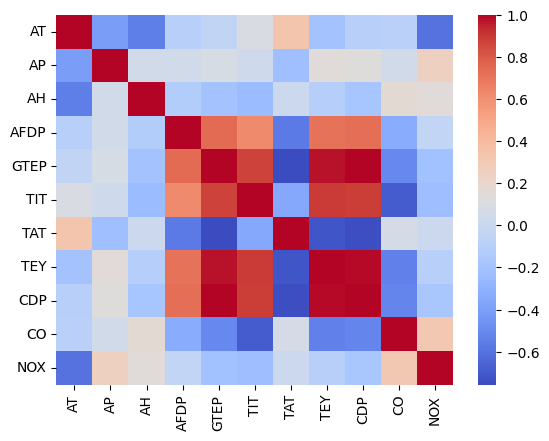

In [7]:
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [8]:
X = df.drop("TEY", axis=1)

y = df["TEY"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
model = Sequential()

model.add(Dense(64, activation="relu", input_dim=X_train.shape[1]))

model.add(Dense(32, activation="relu"))

model.add(Dense(16, activation="relu"))

model.add(Dense(1))

C:\Users\NARENDRA\anaconda3\envs\AI\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6724.6162 - mae: 63.5648 - val_loss: 361.3968 - val_mae: 14.8006
Epoch 2/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 226.4276 - mae: 11.4286 - val_loss: 170.0626 - val_mae: 9.5959
Epoch 3/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 118.6512 - mae: 7.9995 - val_loss: 107.3374 - val_mae: 7.1881
Epoch 4/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 75.2235 - mae: 6.1282 - val_loss: 70.5856 - val_mae: 5.6513
Epoch 5/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 50.9603 - mae: 4.8867 - val_loss: 48.0784 - val_mae: 4.5420
Epoch 6/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 34.0849 - mae: 3.9243 - val_loss: 32.0493 - val_mae: 3.6113
Epoch 7/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22.7003 - mae: 3.1192 - val_loss: 20.3415 - val_mae: 2.8155
Epoch 8/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.0019 - mae: 2.5232 - val_loss: 13.7345 - val_mae: 2.3742
Epoch 9/50
301/301 ━━━━━━━━━━━

In [14]:
predictions = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   


In [15]:
mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("RMSE =", rmse)
print("MAE =", mae)
print("R2 Score =", r2)

RMSE = 0.8021823006520732
MAE = 0.6059098735768743
R2 Score = 0.997430019465926


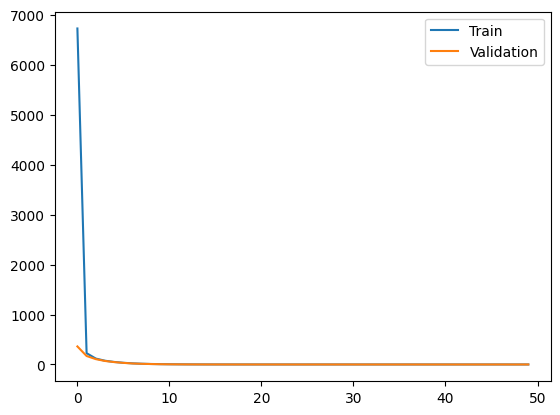

In [16]:
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
# Forest Fires

In [17]:
df=pd.read_csv(r"C:\Users\NARENDRA\Downloads\Neural Network - Assignment 7\forestfires.csv")
df.head()

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep,size_category
0,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,1,0,0,0,0,small
1,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,0,0,0,0,0,0,0,1,0,small
2,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,0,0,0,0,0,0,0,1,0,small
3,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,0,0,0,0,1,0,0,0,0,small
4,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,0,0,0,0,1,0,0,0,0,small


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          517 non-null    object 
 1   day            517 non-null    object 
 2   FFMC           517 non-null    float64
 3   DMC            517 non-null    float64
 4   DC             517 non-null    float64
 5   ISI            517 non-null    float64
 6   temp           517 non-null    float64
 7   RH             517 non-null    int64  
 8   wind           517 non-null    float64
 9   rain           517 non-null    float64
 10  area           517 non-null    float64
 11  dayfri         517 non-null    int64  
 12  daymon         517 non-null    int64  
 13  daysat         517 non-null    int64  
 14  daysun         517 non-null    int64  
 15  daythu         517 non-null    int64  
 16  daytue         517 non-null    int64  
 17  daywed         517 non-null    int64  
 18  monthapr  

In [19]:
df.isnull().sum()

month            0
day              0
FFMC             0
DMC              0
DC               0
ISI              0
temp             0
RH               0
wind             0
rain             0
area             0
dayfri           0
daymon           0
daysat           0
daysun           0
daythu           0
daytue           0
daywed           0
monthapr         0
monthaug         0
monthdec         0
monthfeb         0
monthjan         0
monthjul         0
monthjun         0
monthmar         0
monthmay         0
monthnov         0
monthoct         0
monthsep         0
size_category    0
dtype: int64

In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
encoder = LabelEncoder()

df["month"] = encoder.fit_transform(df["month"])

df["day"] = encoder.fit_transform(df["day"])

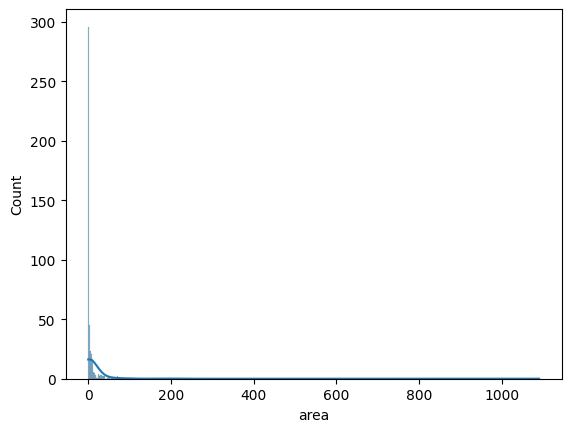

In [23]:
sns.histplot(
    df["area"],
    kde=True
)

plt.show()

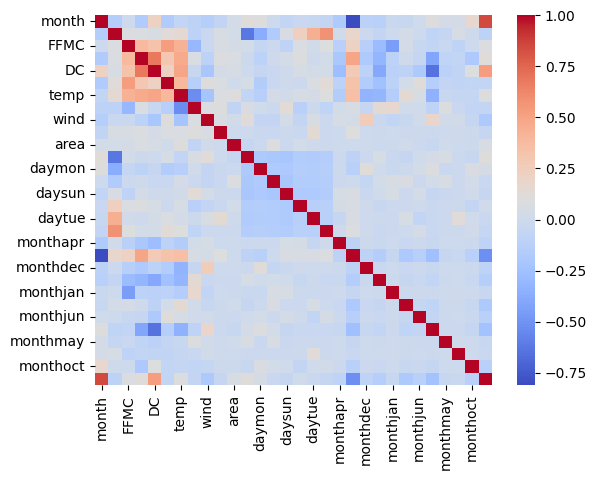

In [24]:
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [25]:
X = df.drop("area", axis=1)

y = df["area"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

ValueError: could not convert string to float: 'small'

In [33]:
print(df.dtypes)

month              int64
day                int64
FFMC             float64
DMC              float64
DC               float64
ISI              float64
temp             float64
RH                 int64
wind             float64
rain             float64
area             float64
dayfri             int64
daymon             int64
daysat             int64
daysun             int64
daythu             int64
daytue             int64
daywed             int64
monthapr           int64
monthaug           int64
monthdec           int64
monthfeb           int64
monthjan           int64
monthjul           int64
monthjun           int64
monthmar           int64
monthmay           int64
monthnov           int64
monthoct           int64
monthsep           int64
size_category      int64
dtype: object


In [30]:
encoder = LabelEncoder()

df["month"] = encoder.fit_transform(df["month"])
df["day"] = encoder.fit_transform(df["day"])
df["size_category"] = encoder.fit_transform(df["size_category"])

In [31]:
X = df.drop("area", axis=1)

y = df["area"]

In [34]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

ValueError: could not convert string to float: 'small'

In [35]:
print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


In [36]:
print(X.dtypes)

month              int64
day                int64
FFMC             float64
DMC              float64
DC               float64
ISI              float64
temp             float64
RH                 int64
wind             float64
rain             float64
dayfri             int64
daymon             int64
daysat             int64
daysun             int64
daythu             int64
daytue             int64
daywed             int64
monthapr           int64
monthaug           int64
monthdec           int64
monthfeb           int64
monthjan           int64
monthjul           int64
monthjun           int64
monthmar           int64
monthmay           int64
monthnov           int64
monthoct           int64
monthsep           int64
size_category      int64
dtype: object


In [37]:
for col in X.columns:
    print(col, X[col].dtype)

month int64
day int64
FFMC float64
DMC float64
DC float64
ISI float64
temp float64
RH int64
wind float64
rain float64
dayfri int64
daymon int64
daysat int64
daysun int64
daythu int64
daytue int64
daywed int64
monthapr int64
monthaug int64
monthdec int64
monthfeb int64
monthjan int64
monthjul int64
monthjun int64
monthmar int64
monthmay int64
monthnov int64
monthoct int64
monthsep int64
size_category int64


In [38]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          517 non-null    int64  
 1   day            517 non-null    int64  
 2   FFMC           517 non-null    float64
 3   DMC            517 non-null    float64
 4   DC             517 non-null    float64
 5   ISI            517 non-null    float64
 6   temp           517 non-null    float64
 7   RH             517 non-null    int64  
 8   wind           517 non-null    float64
 9   rain           517 non-null    float64
 10  dayfri         517 non-null    int64  
 11  daymon         517 non-null    int64  
 12  daysat         517 non-null    int64  
 13  daysun         517 non-null    int64  
 14  daythu         517 non-null    int64  
 15  daytue         517 non-null    int64  
 16  daywed         517 non-null    int64  
 17  monthapr       517 non-null    int64  
 18  monthaug  

In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

ValueError: could not convert string to float: 'small'

In [40]:
X = X.fillna(X.mean())

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
print(type(X))

print(X.dtypes.unique())

<class 'pandas.core.frame.DataFrame'>
[dtype('int64') dtype('float64')]


In [43]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [44]:
model = Sequential()

model.add(Dense(64,
                activation="relu",
                input_dim=X_train.shape[1]))

model.add(Dense(32,
                activation="relu"))

model.add(Dense(16,
                activation="relu"))

model.add(Dense(1))

C:\Users\NARENDRA\anaconda3\envs\AI\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [46]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 2594.0662 - mae: 12.1570 - val_loss: 620.7806 - val_mae: 7.1371
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2572.2112 - mae: 12.0763 - val_loss: 604.8230 - val_mae: 7.0927
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2536.1873 - mae: 12.0704 - val_loss: 582.6290 - val_mae: 7.2719
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2479.8049 - mae: 12.3060 - val_loss: 558.9260 - val_mae: 8.0256
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2415.7219 - mae: 12.9654 - val_loss: 539.1357 - val_mae: 9.1550
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2345.3003 - mae: 13.6783 - val_loss: 525.6286 - val_mae: 9.9751
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2280.0132 - mae: 14.0821 - val_loss: 509.2898 - val_mae: 10.4068
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2224.9241 - mae: 14.3581 - val_loss: 500.1859 - val_mae: 10.6432
Epoch 9/50
21/21 ━━━━

In [47]:
predictions = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step 


In [48]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("RMSE =", rmse)

print("R2 Score =", r2)

RMSE = 98.86743361590236
R2 Score = 0.1707697076257202


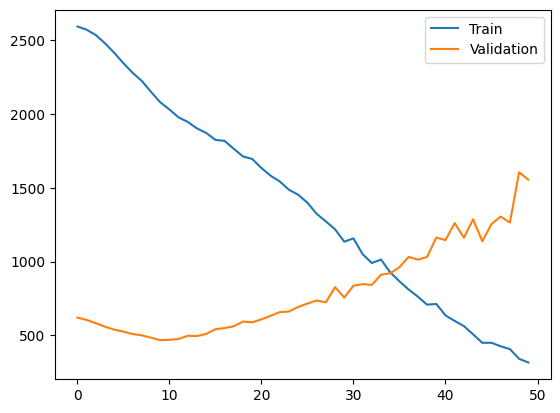

In [49]:
plt.plot(
    history.history["loss"]
)

plt.plot(
    history.history["val_loss"]
)

plt.legend(
    ["Train", "Validation"]
)

plt.show()